In [1]:
import os
import sys
from pathlib import Path

project_root = Path.cwd().parent.parent
os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
    
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

Импортируем данные

P.S.: Перед запуском выполнить python -m lab4.src.utils.download_data

In [2]:
from sklearn.model_selection import train_test_split
from lab4.src.text_processor import TextDataProcessor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

from lab4.config import Config
config = Config()

train_path = Path(config.target_dir) / "train.csv"

df = pd.read_csv(train_path).set_index("id")
X = df["comment_text"]
y = df.drop(columns=["comment_text"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# Пайплайн обработки текста
prep = Pipeline([
   # Чистка текста
    ('cleaner', TextDataProcessor()),
   #  Векторизация (TF-IDF)
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
])

# очистка + tfidf
X_train_features = prep.fit_transform(X_train)  # train+eval для X_train (обучаем и сохраняем веса tf-idf)
X_test_features = prep.transform(X_test) # eval для X_test (применяем ранее обученные веса tf-idf на тестовую выборку)

# Про tf-idf: https://habr.com/ru/companies/otus/articles/755772/

Cleaning text: 100%|██████████| 23936/23936 [00:41<00:00, 579.38it/s]


Пороги модели

In [3]:
# Пороги настраиваем в ручную (без оптимизации)
THRESHOLDS = {
    "toxic": 0.30,
    "severe_toxic": 0.15,
    "obscene": 0.30,
    "threat": 0.10,
    "insult": 0.25,
    "identity_hate": 0.15,
}

1) Настраиваем pipeline для Логистической регрессии (LogisticRegression)

In [4]:
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression


# В LogisticRegression зашита сигмоида; оптимизатор - "lbfgs". На иницилизации веса произвольные 
# Solver выбрали по рекомендациям из интернета (быстрее для классификации)
clf_lr = MultiOutputClassifier(
       LogisticRegression(class_weight="balanced", solver="liblinear")
   )


# Считаем всё необходимое для метрик (вероятности)
def compute_predictions(clf, X_features, y_test, thresholds=None) -> dict:
    
    class_names = list(y_test.columns)
    n_classes = len(class_names)

	 # Конкретная итоговая метрика строки - 0 или 1 по каждому классу
    y_pred = clf.predict(X_features)
    
    # Вероятность между [0,1] по принадлежности строки к определенному классу
    raw = clf.predict_proba(X_features)
    proba = np.zeros((X_features.shape[0], n_classes))
    for i in range(n_classes):
        proba[:, i] = raw[i][:, 1]

	 # Пороги
    if thresholds is None:
        thr = np.full(n_classes, 0.5)
    else:
        thr = np.array([thresholds[name] for name in class_names])

    y_pred = (proba >= thr).astype(int)

    return {
        "class_names": class_names, "n_classes": n_classes,
        "y_true": y_test.values, "y_pred": y_pred, "proba": proba,
        "thresholds": thr,
    }

Обучение

In [5]:
clf_lr.fit(X_train_features, y_train)

,estimator estimator: estimator objectAn estimator object implementing :term:`fit` and :term:`predict`.A :term:`predict_proba` method will be exposed only if `estimator` implementsit.,LogisticRegre...r='liblinear')
,"n_jobs n_jobs: int or None, optional (default=None)The number of jobs to run in parallel.:meth:`fit`, :meth:`predict` and :meth:`partial_fit` (if supportedby the passed estimator) will be parallelized for each target.When individual estimators are fast to train or predict,using ``n_jobs > 1`` can result in slower performance dueto the parallelism overhead.``None`` means `1` unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all available processes / threads.See :term:`Glossary <n_jobs>` for more details... versionchanged:: 0.20 `n_jobs` default changed from `1` to `None`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)Class labels.",list,"[array([0, 1]), array([0, 1]), array([0, 1]), array([0, 1]), ...]"
estimators_ estimators_: list of ``n_output`` estimatorsEstimators used for predictions.,list,"[LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), LogisticRegre...r='liblinear'), ...]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying `estimator` exposes such an attribute when fit... versionadded:: 0.24,int,10000
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically t

In [6]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(clf_lr) 

preds_lr = compute_predictions(clf_lr, X_test_features, y_test, THRESHOLDS)

Вывод метрик

In [7]:
from sklearn.metrics import (
   roc_auc_score, roc_curve,
   average_precision_score, precision_recall_curve,
   classification_report, multilabel_confusion_matrix,
)

# Подбираем параметры под каждый класс

def evaluate_multilabel_model(preds: dict) -> dict:

	class_names = preds["class_names"]
	n_classes = preds["n_classes"]
	y_true = preds["y_true"]
	y_pred = preds["y_pred"]
	proba = preds["proba"] 
  
   # Считаем ROC-AUC и PR-AUC
	roc_scores, pr_scores = {}, {}
	for i, name in enumerate(class_names):
		if len(np.unique(y_true[:, i])) < 2:
			roc_scores[name] = np.nan
			pr_scores[name] = np.nan
			continue
		roc_scores[name] = roc_auc_score(y_true[:, i], proba[:, i])
		pr_scores[name] = average_precision_score(y_true[:, i], proba[:, i])

	mean_roc = np.nanmean(list(roc_scores.values()))
	mean_pr = np.nanmean(list(pr_scores.values()))
    
   # Графики ROC-AUC
	plt.figure(figsize=(8, 6))
	for i, name in enumerate(class_names):
		if np.isnan(roc_scores[name]):
			continue
		fpr, tpr, _ = roc_curve(y_true[:, i], proba[:, i])
		plt.plot(fpr, tpr, label=f"{name} (AUC={roc_scores[name]:.3f})")
	plt.plot([0, 1], [0, 1], "k--", alpha=0.4)      # линия случайного угадывания
	plt.xlabel("FPR")
	plt.ylabel("TPR")
	plt.title(f"ROC-кривые по меткам | средний ROC-AUC = {mean_roc:.3f}")
	plt.legend(loc="lower left", fontsize=9)
	plt.tight_layout()
	plt.show()

   # Графики PR-AUC
	plt.figure(figsize=(8, 6))
	for i, name in enumerate(class_names):
		if np.isnan(pr_scores[name]):
			continue
		prec, rec, _ = precision_recall_curve(y_true[:, i], proba[:, i])
		plt.plot(rec, prec, label=f"{name} (AP={pr_scores[name]:.3f})")
	plt.xlabel("Recall")
	plt.ylabel("Precision")
	plt.title(f"Precision-Recall кривые | средний PR-AUC = {mean_pr:.3f}")
	plt.legend(loc="lower left", fontsize=9)
	plt.tight_layout()
	plt.show()

   # Графики ROC-AUC vs PR-AUC
	x = np.arange(n_classes)
	w = 0.35
	plt.figure(figsize=(9, 5))
	plt.bar(x - w/2, [roc_scores[n] for n in class_names], w, label="ROC-AUC")
	plt.bar(x + w/2, [pr_scores[n] for n in class_names], w, label="PR-AUC")
	plt.xticks(x, class_names, rotation=30, ha="right")
	plt.ylim(0, 1)
	plt.ylabel("Значение")
	plt.title("ROC-AUC и PR-AUC по каждой метке")
	plt.legend()
	plt.tight_layout()
	plt.show()

	# Сonfusion_matrix
	mcm = multilabel_confusion_matrix(y_true, y_pred)
	fig, axes = plt.subplots(2, 3, figsize=(12, 8))
	for ax, name, cm in zip(axes.ravel(), class_names, mcm):
		ax.imshow(cm, cmap="Blues")
		ax.set_title(name)
		ax.set_xticks([0, 1]); ax.set_xticklabels(["a(x)=0", "a(x)=1"])
		ax.set_yticks([0, 1]); ax.set_yticklabels(["y=0", "y=1"])
		for r in range(2):
			for c in range(2):
					ax.text(c, r, cm[r, c], ha="center", va="center",
							color="black", fontsize=12)
	fig.suptitle("Матрицы ошибок по меткам (TN FP / FN TP)")
	plt.tight_layout()
	plt.show()

	# precision / recall / f1
	print("\n=== Отчёт по меткам ===")
	for i, name in enumerate(class_names):
		print(f"\n--- {name} ---")
		print(classification_report(y_true[:, i], y_pred[:, i], zero_division=0))

	return {
		"roc_auc": roc_scores, "pr_auc": pr_scores,
		"mean_roc_auc": mean_roc, "mean_pr_auc": mean_pr,
	}

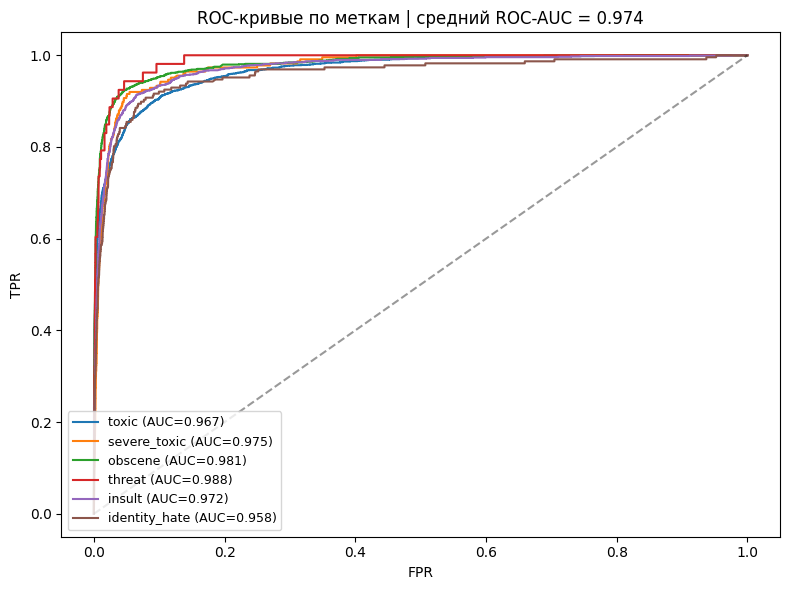

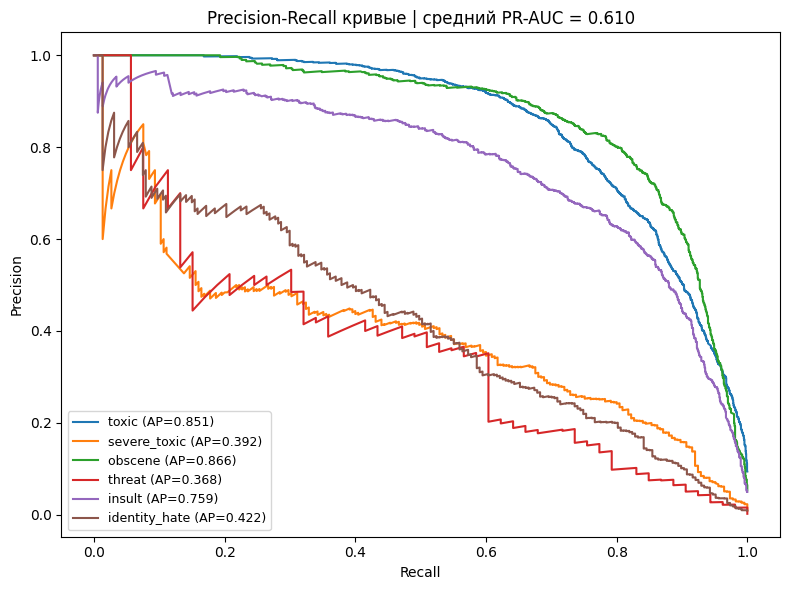

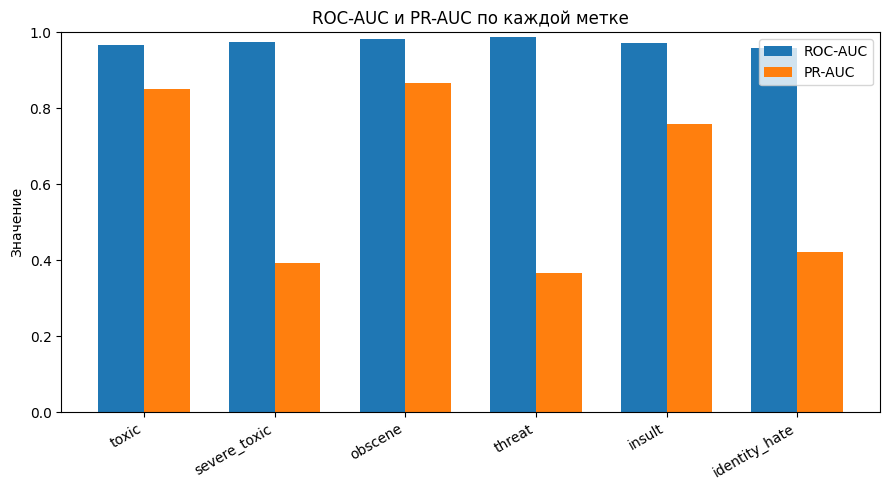

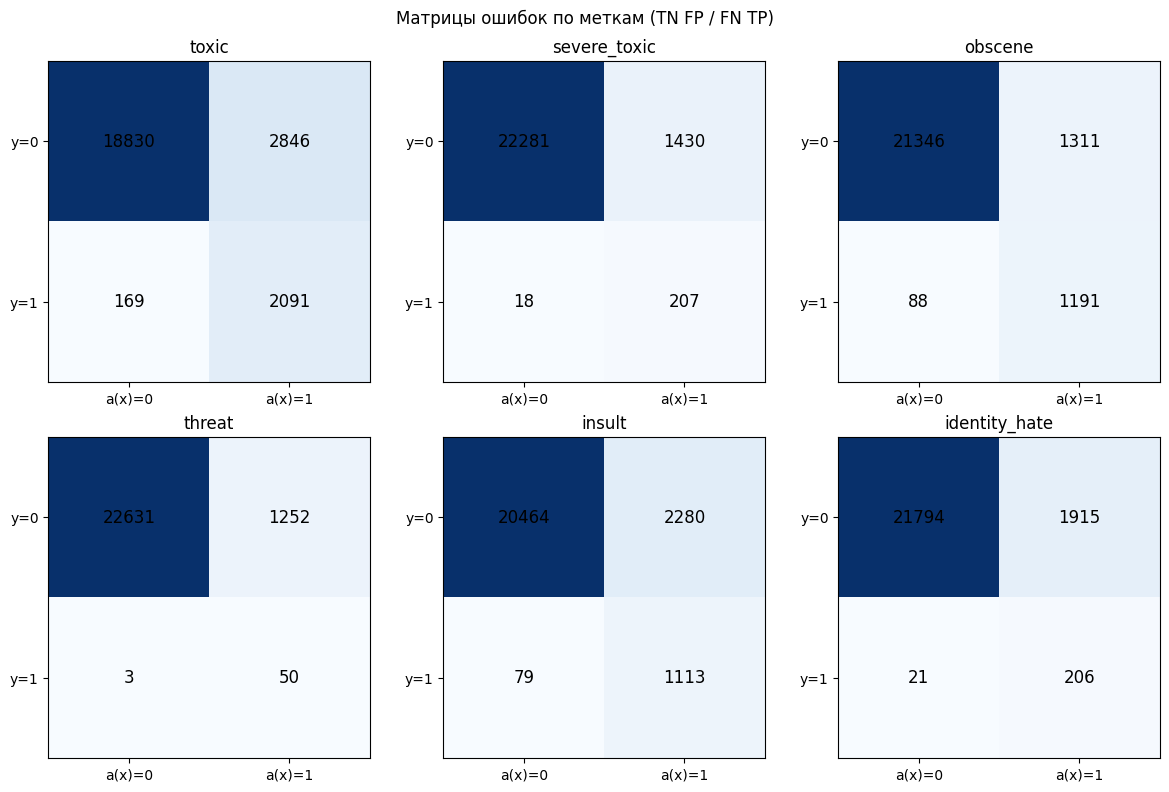


=== Отчёт по меткам ===

--- toxic ---
              precision    recall  f1-score   support

           0       0.99      0.87      0.93     21676
           1       0.42      0.93      0.58      2260

    accuracy                           0.87     23936
   macro avg       0.71      0.90      0.75     23936
weighted avg       0.94      0.87      0.89     23936


--- severe_toxic ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     23711
           1       0.13      0.92      0.22       225

    accuracy                           0.94     23936
   macro avg       0.56      0.93      0.60     23936
weighted avg       0.99      0.94      0.96     23936


--- obscene ---
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     22657
           1       0.48      0.93      0.63      1279

    accuracy                           0.94     23936
   macro avg       0.74      0.94      0.80     2

In [8]:
metrics = evaluate_multilabel_model(preds_lr)

print(f"Средний ROC-AUC: {metrics['mean_roc_auc']:.4f}")
print(f"Средний PR-AUC: {metrics['mean_pr_auc']:.4f}")

print("\nROC-AUC по меткам:")
for label, score in metrics["roc_auc"].items():
    print(f"  {label:15}: {score:.4f}")

print("\nPR-AUC по меткам:")
for label, score in metrics["pr_auc"].items():
    print(f"  {label:15}: {score:.4f}")

Вывод FN и FP

In [ ]:
def show_errors(preds: dict, X_test, label_name, n_examples=10):
    
    class_names = preds["class_names"]
    idx = class_names.index(label_name)

    y_true = preds["y_true"][:, idx]
    y_pred = preds["y_pred"][:, idx]
    proba = preds["proba"][:, idx]

    X_arr = np.array(X_test)  # исходные тексты

    fn_mask = (y_true == 1) & (y_pred == 0) # FN
    fp_mask = (y_true == 0) & (y_pred == 1) # FP

    fn_idx = np.where(fn_mask)[0]
    fp_idx = np.where(fp_mask)[0]

    # Сортировка
    fn_idx = fn_idx[np.argsort(proba[fn_idx])]
    fp_idx = fp_idx[np.argsort(-proba[fp_idx])]

    print(f"Метка: {label_name} | FN: {len(fn_idx)}  FP: {len(fp_idx)}")

    print(f"\n--- FN, топ {n_examples} ---")
    for i in fn_idx[:n_examples]:
        print(f"[p={proba[i]:.2f}] {str(X_arr[i])[:200]}")

    print(f"\n--- FP, топ {n_examples} ---")
    for i in fp_idx[:n_examples]:
        print(f"[p={proba[i]:.2f}] {str(X_arr[i])[:200]}")

    return {"fn_indices": fn_idx, "fp_indices": fp_idx}

In [ ]:
show_errors(preds_lr, X_test, "toxic", n_examples=10)
# show_errors(preds_lr, X_test"severe_toxic", n_examples=10)
# show_errors(preds_lr, X_test, "obscene", n_examples=10)
# show_errors(preds_lr, X_test, "threat", n_examples=10)
# show_errors(preds_lr, X_test, "insult", n_examples=10)
# show_errors(preds_lr, X_test, "identity_hate", n_examples=10)

2) Настраиваем pipeline для RandomForest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = MultiOutputClassifier(
       RandomForestClassifier(
          n_estimators=75, 
          max_depth=30, 
          min_samples_leaf=5, 
         #  class_weight="balanced_subsample", 
          random_state=42,
          n_jobs=-2,
          ),
       n_jobs=-2,
       )

Обучение

In [ ]:
clf_rf.fit(X_train_features, y_train)

In [ ]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(clf_rf) 

preds_rf = compute_predictions(clf_rf, X_test_features, y_test, THRESHOLDS)

Вывод метрик

In [ ]:
metrics = evaluate_multilabel_model(preds_rf)

print(f"Средний ROC-AUC: {metrics['mean_roc_auc']:.4f}")
print(f"Средний PR-AUC: {metrics['mean_pr_auc']:.4f}")

print("\nROC-AUC по меткам:")
for label, score in metrics["roc_auc"].items():
    print(f"  {label:15}: {score:.4f}")

print("\nPR-AUC по меткам:")
for label, score in metrics["pr_auc"].items():
    print(f"  {label:15}: {score:.4f}")

Вывод ошибок

In [ ]:
show_errors(preds_rf, X_test, "toxic", n_examples=10)
# show_errors(preds_rf, X_test, "severe_toxic", n_examples=10)
# show_errors(preds_rf, X_test, "obscene", n_examples=10)
# show_errors(preds_rf, X_test, "threat", n_examples=10)
# show_errors(preds_rf, X_test, "insult", n_examples=10)
# show_errors(preds_rf, X_test, "identity_hate", n_examples=10)

3) Настраиваем pipeline для Линейного SVM (LinearSVC)

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

clf_svm = MultiOutputClassifier(
    CalibratedClassifierCV(
        LinearSVC(
           class_weight="balanced", C=1.0, max_iter=5000
           ),
        method="sigmoid",
    ),
    n_jobs=-2,
)

Обучение

In [ ]:
clf_svm.fit(X_train_features, y_train)

In [ ]:
from sklearn.utils.validation import check_is_fitted

check_is_fitted(clf_svm) 

preds_svm = compute_predictions(clf_svm, X_test_features, y_test, THRESHOLDS)

Вывод метрик

In [ ]:
metrics = evaluate_multilabel_model(preds_svm,)

print(f"Средний ROC-AUC: {metrics['mean_roc_auc']:.4f}")
print(f"Средний PR-AUC: {metrics['mean_pr_auc']:.4f}")

print("\nROC-AUC по меткам:")
for label, score in metrics["roc_auc"].items():
    print(f"  {label:15}: {score:.4f}")

print("\nPR-AUC по меткам:")
for label, score in metrics["pr_auc"].items():
    print(f"  {label:15}: {score:.4f}")

Вывод ошибок

In [ ]:
show_errors(preds_svm, X_test, "toxic", n_examples=10)
# show_errors(pipeline_svm, X_test, "severe_toxic", n_examples=10)
# show_errors(pipeline_svm, X_test, "obscene", n_examples=10)
# show_errors(pipeline_svm, X_test, "threat", n_examples=10)
# show_errors(pipeline_svm, X_test, "insult", n_examples=10)
# show_errors(pipeline_svm, X_test, "identity_hate", n_examples=10)